In [ ]:
Understanding the Building Blocks

At the heart of these models are concepts related to how a time series value relates to its own past values or past forecast errors.
-----------------------------------------------------------------------------------------------------
1. Autoregressive (AR) Models

    Concept: An AR model assumes that the current value of a time series (Y_t) can be expressed as a linear combination of its own past values (Y_t−1,Y_t−2,dots,Y_t−p) plus a random error term (epsilon_t).

    Order (p): The 'p' in AR(p) denotes the number of past observations used in the model.

    Formula: Y_t=c+phi_1Y_t−1+phi_2Y_t−2+dots+phi_pY_t−p+epsilon_t

        c: A constant (intercept).

        phi_i: Autoregressive coefficients, representing the impact of past values.

        epsilon_t: White noise error term (random shock).

    Assumption: The series must be stationary (constant mean, variance, and autocorrelation over time). If not, it needs to be differenced first.

    Intuition: If a series shows a strong correlation with its recent past values (e.g., if today's stock price is heavily influenced by yesterday's or the day before's price), an AR model might be suitable.
-----------------------------------------------------------------------------------------------------
2. Moving Average (MA) Models

    Concept: An MA model assumes that the current value of a time series (Y_t) can be expressed as a linear combination of its current and past white noise error terms (epsilon_t,epsilon_t−1,dots,epsilon_t−q). These error terms are typically unobservable, so the model focuses on the relationship with past forecast errors.

    Order (q): The 'q' in MA(q) denotes the number of past forecast error terms used in the model.

    Formula: Y_t=c+epsilon_t+theta_1epsilon_t−1+theta_2epsilon_t−2+dots+theta_qepsilon_t−q

        c: A constant.

        theta_i: Moving average coefficients, representing the impact of past errors.

        epsilon_t: White noise error term.

    Assumption: The series must be stationary.

    Intuition: If a series has "memory" of past shocks or random fluctuations (e.g., if a sudden, unexpected increase in sales last month continues to have an effect this month), an MA model might be appropriate.
-----------------------------------------------------------------------------------------------------
3. Autoregressive Moving Average (ARMA) Models

    Concept: An ARMA model combines the AR and MA components. It's suitable for stationary time series that exhibit both autoregressive and moving average characteristics.

    Order (p, q): ARMA(p, q) indicates 'p' autoregressive terms and 'q' moving average terms.

    Formula: Y_t=c+phi_1Y_t−1+dots+phi_pY_t−p+epsilon_t+theta_1epsilon_t−1+dots+theta_qepsilon_t−q

    Assumption: The series must be stationary.

    Intuition: If the series' behavior depends on both its own past values and past unpredictable shocks.
-----------------------------------------------------------------------------------------------------
4. Autoregressive Integrated Moving Average (ARIMA) Models

    Concept: ARIMA models extend ARMA models to handle non-stationary time series by introducing the concept of differencing. The 'I' stands for "Integrated."

    Order (p, d, q):

        p: Order of the AR part.

        d: Order of differencing required to make the series stationary.

        q: Order of the MA part.

    Process:

        Differencing (d): The series is differenced d times until it becomes stationary.

        ARMA Modeling: An ARMA(p, q) model is then applied to the differenced (stationary) series.

    Intuition: ARIMA is ideal for series with a trend (which can be removed by differencing). If a series grows linearly, one differencing (d=1) often makes it stationary.
-----------------------------------------------------------------------------------------------------
5. Seasonal Autoregressive Integrated Moving Average (SARIMA) Models

    Concept: SARIMA models extend ARIMA models to handle time series that exhibit seasonality in addition to trends and other non-stationarities.

    Order (p, d, q)(P, D, Q, s):

        (p, d, q): Non-seasonal orders (same as ARIMA).

        (P, D, Q, s): Seasonal orders:

            P: Seasonal Autoregressive order.

            D: Seasonal Differencing order.

            Q: Seasonal Moving Average order.

            s: Number of periods in a seasonal cycle (e.g., 12 for monthly data with annual seasonality, 24 for hourly data with daily seasonality).

    Process:

        Seasonal Differencing (D): The series is differenced by s periods (Y_t - Y_{t-s}) D times to remove seasonal non-stationarity.

        Non-Seasonal Differencing (d): The resulting series is then differenced d times to remove any remaining non-seasonal trend.

        ARMA Modeling: An ARMA(p, q) model is applied to the differenced series, and a seasonal ARMA(P, Q) model is applied to the seasonally differenced series.

    Intuition: For data with repeating patterns at fixed intervals (like monthly sales, hourly electricity consumption), SARIMA can capture both the overall trend and the consistent seasonal fluctuations.

Python Example: Implementing AR, MA, ARMA, ARIMA, SARIMA

We'll use statsmodels for AR/MA/ARMA/ARIMA and pmdarima.auto_arima for SARIMA to simplify order selection.


--- Airline Passengers Data ---
time
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: value, dtype: int64
time
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: value, dtype: int64
Data points: 144


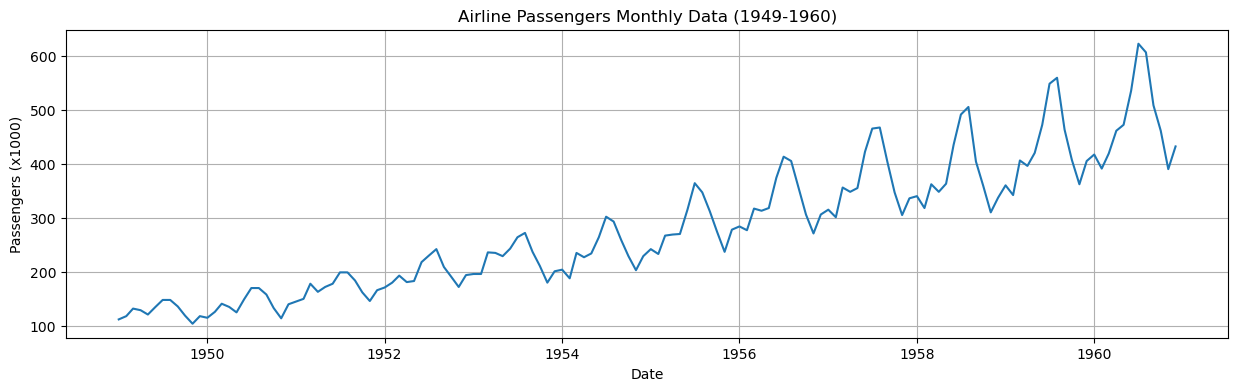

In [46]:
# Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA # Unified ARIMA/ARMA/AR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller # For stationarity testing
import pmdarima as pm # For auto_arima (SARIMA)

import warnings
warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

# --- Data Loading (Using a sample dataset or creating one for demonstration) ---
# Let's create a synthetic dataset first for AR/MA/ARMA clarity
np.random.seed(42)
n_points_synth = 100
synth_index = pd.date_range(start='2020-01-01', periods=n_points_synth, freq='MS')

# Pure AR(1) like data
ar1_data = np.zeros(n_points_synth)
ar1_data[0] = 10 # Initial value
for i in range(1, n_points_synth):
    ar1_data[i] = 0.7 * ar1_data[i-1] + np.random.normal(0, 1)
ar1_series = pd.Series(ar1_data, index=synth_index)

# Pure MA(1) like data (moving average of errors)
ma1_data = np.zeros(n_points_synth)
errors = np.random.normal(0, 1, n_points_synth)
for i in range(1, n_points_synth):
    ma1_data[i] = errors[i] + 0.5 * errors[i-1]
ma1_series = pd.Series(ma1_data, index=synth_index)

# ARIMA (Random Walk with Drift - non-stationary)
# This is an ARIMA(0,1,0) model with a constant term
arima_data = np.cumsum(np.random.normal(0, 1, n_points_synth) + 0.1) # drift of 0.1
arima_series = pd.Series(arima_data, index=synth_index)

# --- Real-world data for ARIMA/SARIMA ---
# Using a simple global temperature dataset (you can replace with your own CSV)
# Source: NASA GISS Surface Temperature Analysis (GISTEMP) data, simplified.
# Data represents global surface temperature anomalies (difference from a baseline average)
# For simplicity, let's create a synthetic one that mimics trend and seasonality
# or use a readily available dataset like `airline_passengers` for SARIMA.

# Option 1: Use `airline_passengers` for SARIMA (very common example)
from statsmodels.datasets import get_rdataset
data_airline = get_rdataset("AirPassengers", "datasets")
airline_series = data_airline.data['value']
years = data_airline.data['time'].apply(int)
months = np.round((data_airline.data['time'] - years) * 12).astype(int) + 1
date_strings = years.astype(str) + '-' + months.astype(str).str.zfill(2)
airline_series.index = pd.to_datetime(date_strings, format='%Y-%m')

# Convert PeriodIndex to DatetimeIndex for broader compatibility
#airline_series.index = airline_series.index.to_timestamp()
print("\n--- Airline Passengers Data ---")
print(airline_series.head())
print(airline_series.tail())
print(f"Data points: {len(airline_series)}")

plt.figure(figsize=(15, 4))
plt.plot(airline_series)
plt.title('Airline Passengers Monthly Data (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Passengers (x1000)')
plt.grid(True)
plt.show()


# --- Helper Function for ADF Test ---
def adf_test_results(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'\n--- Augmented Dickey-Fuller Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f"Conclusion: Reject H0. {name} is likely stationary.")
    else:
        print(f"Conclusion: Fail to reject H0. {name} is likely non-stationary.")

# Helper Function for KPSS test ---1
def kpss_test_results(series, name='Series', regression='c'): # 'c' for constant, 'ct' for constant + trend
    result = kpss(series.dropna(), regression=regression)
    print(f'\n--- KPSS Test for {name} (regression={regression}) ---')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'  {key}: {value:.4f}')
    if result[1] > 0.05:
        print(f"Conclusion: Fail to reject H0. {name} is likely stationary.")
    else:
        print(f"Conclusion: Reject H0. {name} is likely non-stationary.")



--- AR(1) Model Example ---

--- Augmented Dickey-Fuller Test for AR(1) Synthetic Series ---
ADF Statistic: -5.7793
p-value: 0.0000
Critical Values:
  1%: -3.4982
  5%: -2.8912
  10%: -2.5826
Conclusion: Reject H0. AR(1) Synthetic Series is likely stationary.


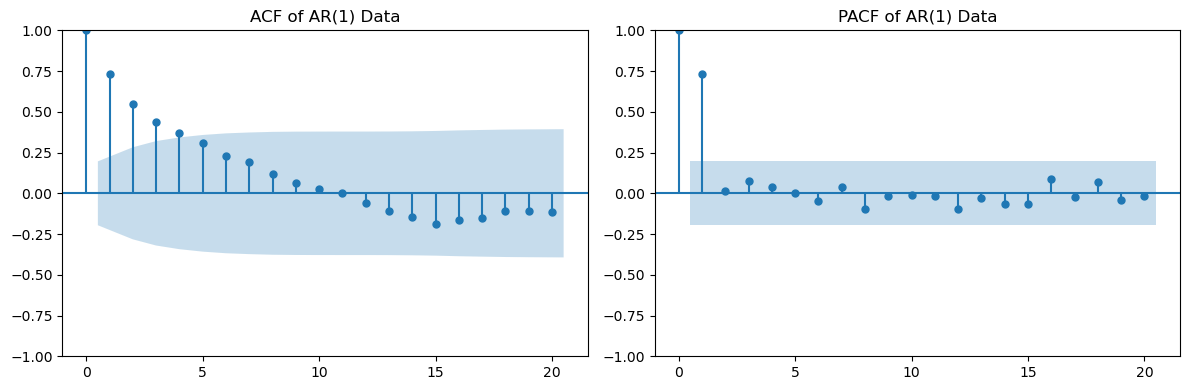

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -147.739
Date:                Tue, 15 Jul 2025   AIC                            301.479
Time:                        11:03:30   BIC                            309.294
Sample:                    01-01-2020   HQIC                           304.642
                         - 04-01-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2601      1.528      0.825      0.410      -1.735       4.255
ar.L1          0.9460      0.024     39.720      0.000       0.899       0.993
sigma2         1.0990      0.150      7.322      0.0

In [47]:
# --- 1. AR Model (on stationary AR(1) synthetic data) ---
print("\n--- AR(1) Model Example ---")
# Check stationarity
adf_test_results(ar1_series, 'AR(1) Synthetic Series') # Should be stationary
kpss_test_results(ar1_series, 'AR(1) Synthetic Series', regression='c') # Should be stationary  # 'c' for constant, 'ct' for constant + trend
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ar1_series, ax=axes[0], lags=20, title='ACF of AR(1) Data')
plot_pacf(ar1_series, ax=axes[1], lags=20, title='PACF of AR(1) Data')
plt.tight_layout()
plt.show()
# For AR(1), ACF should decay exponentially, PACF should have a significant spike at lag 1 only.

# Fit AR(1) model
ar_model = ARIMA(ar1_series, order=(1, 0, 0)) # (p, d, q) -> (1, 0, 0) for AR(1)
ar_fit = ar_model.fit()
print(ar_fit.summary())

# Forecast
ar_forecast_steps = 10
ar_forecast = ar_fit.predict(start=len(ar1_series), end=len(ar1_series) + ar_forecast_steps - 1)
print(f"AR(1) Forecast for next {ar_forecast_steps} steps:\n", ar_forecast)



--- MA(1) Model Example ---

--- Augmented Dickey-Fuller Test for MA(1) Synthetic Series ---
ADF Statistic: -7.1543
p-value: 0.0000
Critical Values:
  1%: -3.4989
  5%: -2.8915
  10%: -2.5828
Conclusion: Reject H0. MA(1) Synthetic Series is likely stationary.


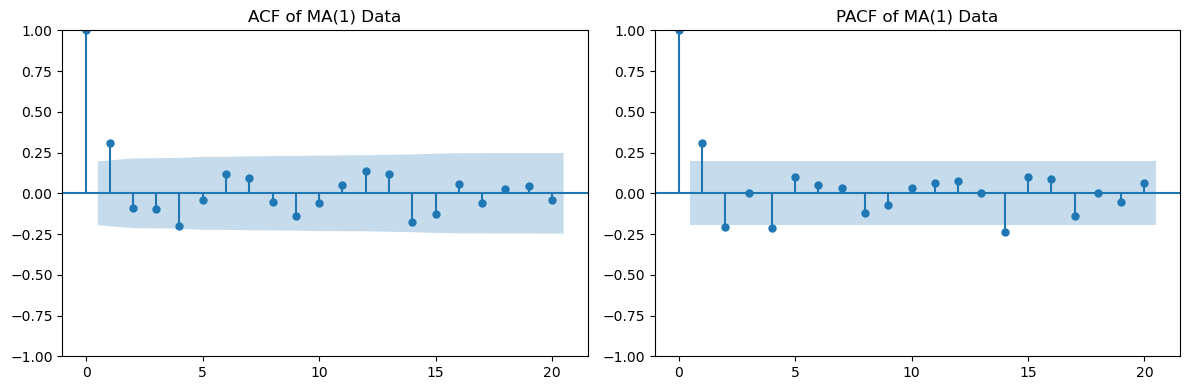

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -136.014
Date:                Tue, 15 Jul 2025   AIC                            278.028
Time:                        11:06:36   BIC                            285.843
Sample:                    01-01-2020   HQIC                           281.191
                         - 04-01-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0513      0.141      0.363      0.717      -0.226       0.329
ma.L1          0.4478      0.101      4.412      0.000       0.249       0.647
sigma2         0.8871      0.129      6.853      0.0

In [48]:
# --- 2. MA Model (on stationary MA(1) synthetic data) ---
print("\n--- MA(1) Model Example ---")
# Check stationarity
adf_test_results(ma1_series, 'MA(1) Synthetic Series') # Should be stationary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ma1_series, ax=axes[0], lags=20, title='ACF of MA(1) Data')
plot_pacf(ma1_series, ax=axes[1], lags=20, title='PACF of MA(1) Data')
plt.tight_layout()
plt.show()
# For MA(1), ACF should have a significant spike at lag 1 only, PACF should decay exponentially.

# Fit MA(1) model
ma_model = ARIMA(ma1_series, order=(0, 0, 1)) # (p, d, q) -> (0, 0, 1) for MA(1)
ma_fit = ma_model.fit()
print(ma_fit.summary())

# Forecast
ma_forecast_steps = 10
ma_forecast = ma_fit.predict(start=len(ma1_series), end=len(ma1_series) + ma_forecast_steps - 1)
print(f"MA(1) Forecast for next {ma_forecast_steps} steps:\n", ma_forecast)



--- ARMA(1,1) Model Example ---

--- Augmented Dickey-Fuller Test for ARMA(1,1) Synthetic Series ---
ADF Statistic: -5.1609
p-value: 0.0000
Critical Values:
  1%: -3.4989
  5%: -2.8915
  10%: -2.5828
Conclusion: Reject H0. ARMA(1,1) Synthetic Series is likely stationary.


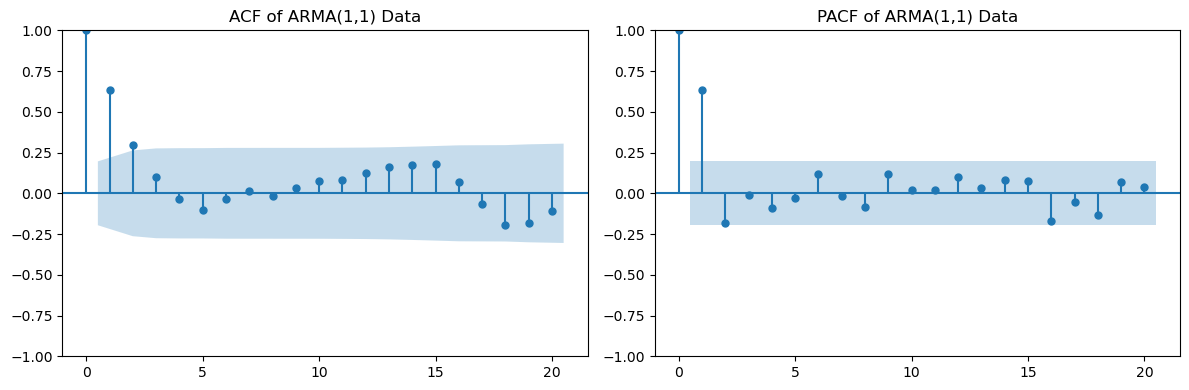

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -135.927
Date:                Tue, 15 Jul 2025   AIC                            279.853
Time:                        11:06:45   BIC                            290.274
Sample:                    01-01-2020   HQIC                           284.071
                         - 04-01-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4243      0.279      1.519      0.129      -0.123       0.972
ar.L1          0.5538      0.110      5.028      0.000       0.338       0.770
ma.L1          0.3474      0.132      2.637      0.0

In [49]:
# --- 3. ARMA Model (on combined synthetic ARMA(1,1) data) ---
print("\n--- ARMA(1,1) Model Example ---")
# Let's create an ARMA(1,1) series for demonstration
arma_data = np.zeros(n_points_synth)
errors_arma = np.random.normal(0, 1, n_points_synth)
arma_data[0] = 5
for i in range(1, n_points_synth):
    arma_data[i] = 0.5 * arma_data[i-1] + errors_arma[i] + 0.3 * errors_arma[i-1]
arma_series = pd.Series(arma_data, index=synth_index)

# Check stationarity
adf_test_results(arma_series, 'ARMA(1,1) Synthetic Series') # Should be stationary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(arma_series, ax=axes[0], lags=20, title='ACF of ARMA(1,1) Data')
plot_pacf(arma_series, ax=axes[1], lags=20, title='PACF of ARMA(1,1) Data')
plt.tight_layout()
plt.show()
# For ARMA, both ACF and PACF might decay or cut off after certain lags depending on dominant terms.

# Fit ARMA(1,1) model
arma_model = ARIMA(arma_series, order=(1, 0, 1)) # (p, d, q) -> (1, 0, 1) for ARMA(1,1)
arma_fit = arma_model.fit()
print(arma_fit.summary())

# Forecast
arma_forecast_steps = 10
arma_forecast = arma_fit.predict(start=len(arma_series), end=len(arma_series) + arma_forecast_steps - 1)
print(f"ARMA(1,1) Forecast for next {arma_forecast_steps} steps:\n", arma_forecast)



--- ARIMA(0,1,0) Model Example (Random Walk) ---

--- Augmented Dickey-Fuller Test for Random Walk Series (Original) ---
ADF Statistic: -2.9806
p-value: 0.0367
Critical Values:
  1%: -3.4989
  5%: -2.8915
  10%: -2.5828
Conclusion: Reject H0. Random Walk Series (Original) is likely stationary.

--- Augmented Dickey-Fuller Test for Random Walk Series (1st Differenced) ---
ADF Statistic: -11.0797
p-value: 0.0000
Critical Values:
  1%: -3.4989
  5%: -2.8915
  10%: -2.5828
Conclusion: Reject H0. Random Walk Series (1st Differenced) is likely stationary.


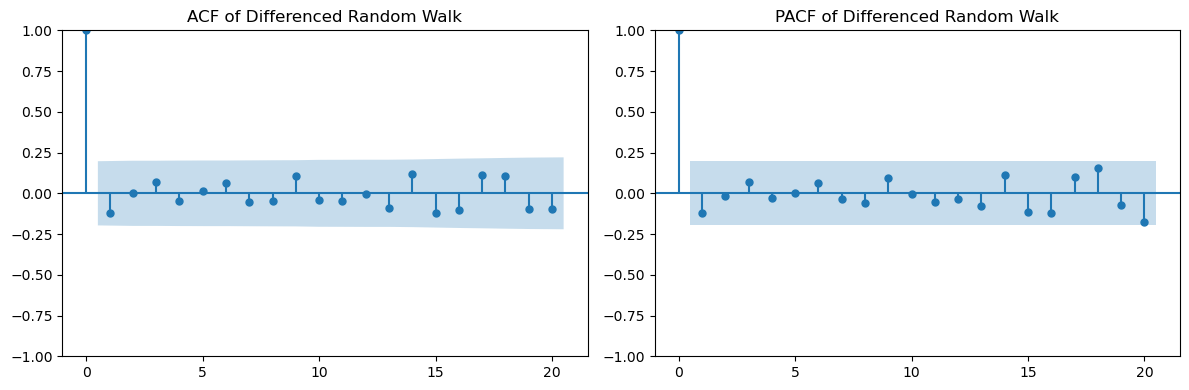

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -149.407
Date:                Tue, 15 Jul 2025   AIC                            300.814
Time:                        11:07:01   BIC                            303.410
Sample:                    01-01-2020   HQIC                           301.864
                         - 04-01-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.1977      0.138      8.703      0.000       0.928       1.467
Ljung-Box (L1) (Q):                   1.56   Jarque-Bera (JB):                 4.68
Prob(Q):                              0.21   Pr

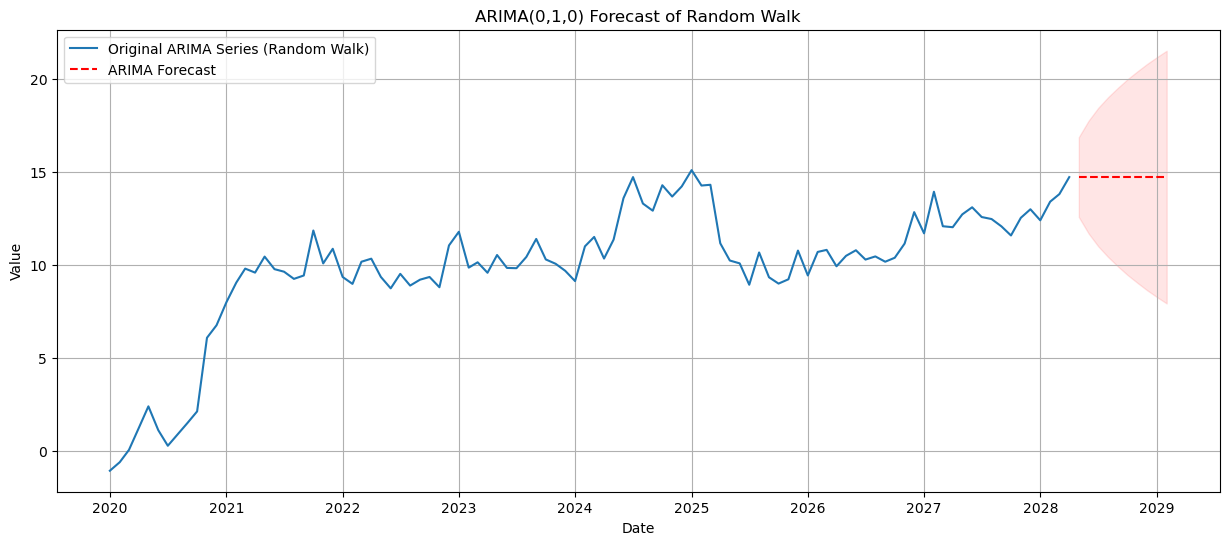

In [50]:
# --- 4. ARIMA Model (on non-stationary Random Walk with Drift) ---
print("\n--- ARIMA(0,1,0) Model Example (Random Walk) ---")
# The random walk is non-stationary
adf_test_results(arima_series, 'Random Walk Series (Original)')

# First difference it to make it stationary (d=1)
arima_diff_series = arima_series.diff().dropna()
adf_test_results(arima_diff_series, 'Random Walk Series (1st Differenced)') # Should be stationary (white noise)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(arima_diff_series, ax=axes[0], lags=20, title='ACF of Differenced Random Walk')
plot_pacf(arima_diff_series, ax=axes[1], lags=20, title='PACF of Differenced Random Walk')
plt.tight_layout()
plt.show()
# For ARIMA(0,1,0) (random walk), the differenced series is white noise.

# Fit ARIMA(0,1,0) model (d=1 is implied by the '1' in the order tuple)
arima_model = ARIMA(arima_series, order=(0, 1, 0)) # (p, d, q) -> (0, 1, 0)
arima_fit = arima_model.fit()
print(arima_fit.summary())

# Forecast
arima_forecast_steps = 10
arima_forecast_results = arima_fit.get_forecast(steps=arima_forecast_steps)
arima_mean_forecast = arima_forecast_results.predicted_mean
arima_conf_int = arima_forecast_results.conf_int()

print(f"ARIMA(0,1,0) Forecast for next {arima_forecast_steps} steps:\n", arima_mean_forecast)

# Plotting ARIMA forecast
plt.figure(figsize=(15, 6))
plt.plot(arima_series, label='Original ARIMA Series (Random Walk)')
plt.plot(arima_mean_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(arima_conf_int.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color='red', alpha=0.1)
plt.title('ARIMA(0,1,0) Forecast of Random Walk')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()


--- SARIMA Model Example (Airline Passengers) ---

--- Augmented Dickey-Fuller Test for Airline Passengers Series ---
ADF Statistic: 0.8154
p-value: 0.9919
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788
Conclusion: Fail to reject H0. Airline Passengers Series is likely non-stationary.


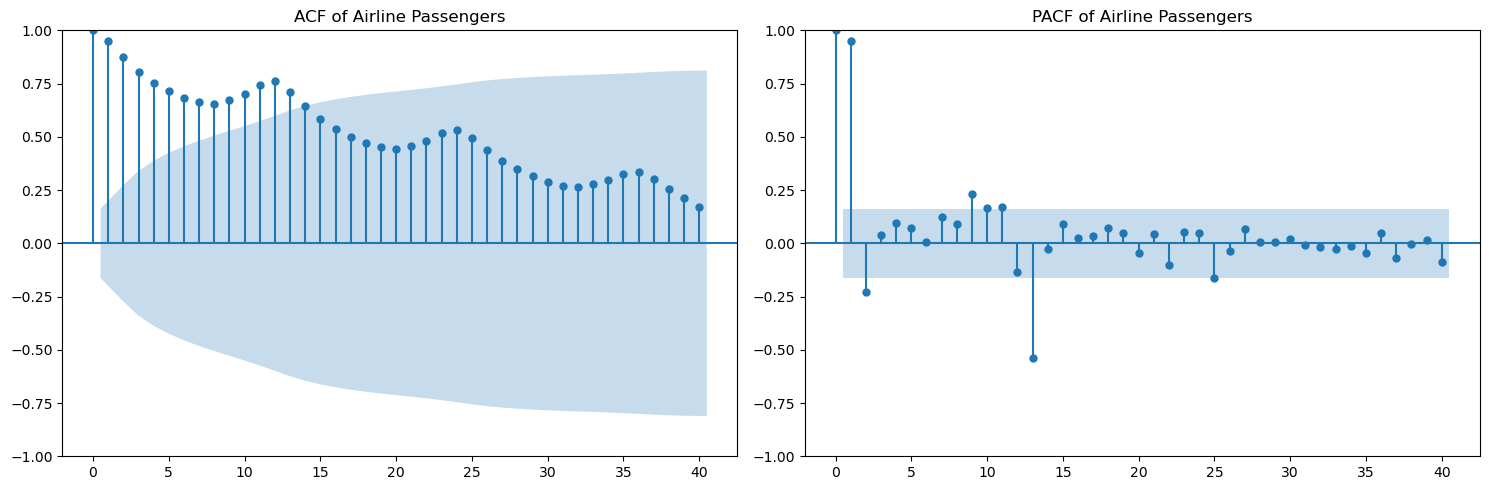


--- After Seasonal Differencing ---

--- Augmented Dickey-Fuller Test for Airline Passengers (Seasonal Diff) ---
ADF Statistic: -3.3830
p-value: 0.0116
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788
Conclusion: Reject H0. Airline Passengers (Seasonal Diff) is likely stationary.

--- After Seasonal and First Differencing ---

--- Augmented Dickey-Fuller Test for Airline Passengers (Seasonal & 1st Diff) ---
ADF Statistic: -15.5956
p-value: 0.0000
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788
Conclusion: Reject H0. Airline Passengers (Seasonal & 1st Diff) is likely stationary.


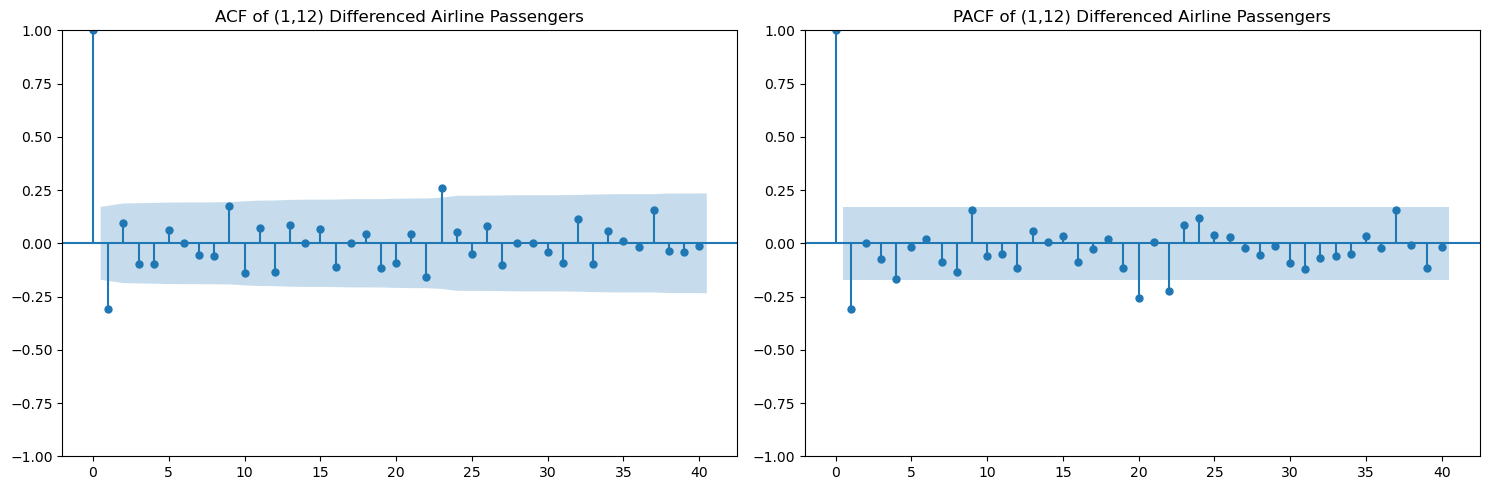

In [51]:
# --- 5. SARIMA Model (on Airline Passengers data) ---
print("\n--- SARIMA Model Example (Airline Passengers) ---")

# Check stationarity of Airline Passengers data
adf_test_results(airline_series, 'Airline Passengers Series') # Likely non-stationary (trend + seasonality)

# Plot ACF/PACF of original series (should show slow decay and seasonal spikes)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(airline_series, ax=axes[0], lags=40, title='ACF of Airline Passengers')
plot_pacf(airline_series, ax=axes[1], lags=40, title='PACF of Airline Passengers')
plt.tight_layout()
plt.show()

# Perform seasonal differencing (lag=12 for monthly data)
airline_diff_seasonal = airline_series.diff(12).dropna()
print("\n--- After Seasonal Differencing ---")
adf_test_results(airline_diff_seasonal, 'Airline Passengers (Seasonal Diff)') # Might still have trend

# Perform first-order differencing on top of seasonal differencing
airline_diff_seasonal_1st = airline_diff_seasonal.diff(1).dropna()
print("\n--- After Seasonal and First Differencing ---")
adf_test_results(airline_diff_seasonal_1st, 'Airline Passengers (Seasonal & 1st Diff)') # Should be stationary

# Plot ACF/PACF of differenced series to identify p,q,P,Q orders
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(airline_diff_seasonal_1st, ax=axes[0], lags=40, title='ACF of (1,12) Differenced Airline Passengers')
plot_pacf(airline_diff_seasonal_1st, ax=axes[1], lags=40, title='PACF of (1,12) Differenced Airline Passengers')
plt.tight_layout()
plt.show()


--- Auto-ARIMA for SARIMA Model Selection ---
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.27 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.08 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.44 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.17 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.58 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.34 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.67 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.88 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.54 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.20 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=2.10 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1020.3

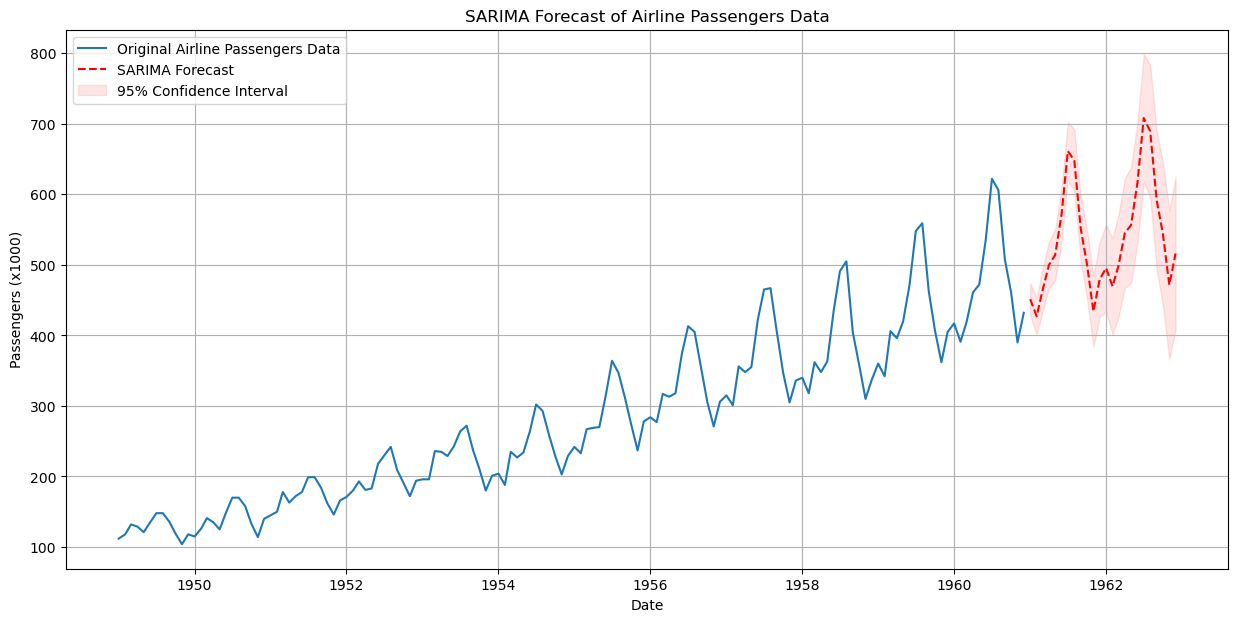

In [52]:
# --- Automated SARIMA order selection with pmdarima ---
# This is highly recommended for SARIMA, as manual selection is complex.
print("\n--- Auto-ARIMA for SARIMA Model Selection ---")
# d=1, D=1, m=12 are typically chosen for AirPassengers due to visual inspection.
# We let auto_arima search for the p, q, P, Q components.
sarima_auto_model = auto_arima(airline_series,
                                start_p=0, start_q=0,
                                max_p=3, max_q=3,
                                m=12,              # Seasonal period
                                d=1, D=1,          # Differencing orders (1 for trend, 1 for seasonality)
                                start_P=0, start_Q=0,
                                max_P=2, max_Q=2,
                                trace=True,        # Show the fitting progress
                                suppress_warnings=True, # Suppress minor warnings
                                stepwise=True,     # Use stepwise search for efficiency
                                seasonal=True,     # Indicate that the series has seasonality
                                error_action='ignore', # Ignore models that fail to converge
                                n_jobs=-1          # Use all CPU cores for faster search
                               )

print(sarima_auto_model.summary())

# Define forecast horizon
forecast_horizon_sarima = 24 # Forecast 24 months (2 years)

# Forecast using the best SARIMA model found by auto_arima
sarima_forecast_results = sarima_auto_model.predict(n_periods=forecast_horizon_sarima, return_conf_int=True)
sarima_mean_forecast = pd.Series(sarima_forecast_results[0], index=pd.date_range(start=airline_series.index[-1] + pd.DateOffset(months=1), periods=forecast_horizon_sarima, freq='MS'))
sarima_conf_int = pd.DataFrame(sarima_forecast_results[1], index=sarima_mean_forecast.index, columns=['lower', 'upper'])

# Plotting SARIMA forecast
plt.figure(figsize=(15, 7))
plt.plot(airline_series, label='Original Airline Passengers Data')
plt.plot(sarima_mean_forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='red', alpha=0.1, label='95% Confidence Interval')
plt.title('SARIMA Forecast of Airline Passengers Data')
plt.xlabel('Date')
plt.ylabel('Passengers (x1000)')
plt.grid(True)
plt.legend()
plt.show()

# Evaluate (simple visual check, formal evaluation would compare against test set)
# Here, we forecasted into the future beyond the available data.

In [ ]:
Explanation of the Code and Observations:

General Setup:

    statsmodels.tsa.arima.model.ARIMA: This is the unified class in statsmodels for fitting AR, MA, ARMA, and ARIMA models. The order tuple (p, d, q) determines which model is fit.

    pmdarima.auto_arima: A highly recommended external library for automatically finding the best SARIMA orders. It simplifies a usually complex trial-and-error process.

    plot_acf, plot_pacf: Autocorrelation Function and Partial Autocorrelation Function plots are essential tools for identifying the p and q (and P, Q) orders.

        AR(p): ACF decays slowly, PACF cuts off after lag p.

        MA(q): ACF cuts off after lag q, PACF decays slowly.

        ARMA(p,q): Both ACF and PACF may decay.

    adfuller: Augmented Dickey-Fuller test for formal stationarity checking.
-----------------------------------------------------------------------------------------------------
Specific Model Examples:

    AR(1) Example:

        We create a synthetic series where each value depends on the previous one.

        order=(1, 0, 0): p=1 (one AR term), d=0 (no differencing, as it's stationary), q=0 (no MA terms).

        ACF plot for AR(1) will typically show an exponential decay, while PACF will cut off after the first lag.
    -----------------------------------------------------------------------------------------------------
    MA(1) Example:

        We create a synthetic series where each value depends on the current and previous error terms.

        order=(0, 0, 1): p=0, d=0, q=1 (one MA term).

        ACF plot for MA(1) will typically show a spike only at the first lag, while PACF will decay exponentially.
    -----------------------------------------------------------------------------------------------------
    ARMA(1,1) Example:

        A synthetic series combining both AR(1) and MA(1) characteristics.

        order=(1, 0, 1): p=1, d=0, q=1.

        Both ACF and PACF might show decays or mixtures of cut-offs, indicating a combined process.
    -----------------------------------------------------------------------------------------------------
    ARIMA(0,1,0) Example (Random Walk):

        A random walk is a classic example of a non-stationary series that becomes stationary after first differencing (d=1).

        order=(0, 1, 0): p=0, d=1 (differencing the series once), q=0.

        The ADF test on the original random walk will confirm non-stationarity. After differencing, it becomes stationary (like white noise), and its ACF/PACF plots will show no significant correlations.

        The forecast of a random walk with no AR/MA terms (beyond the differencing) is simply a flat line extending from the last observed value (or with a drift if a constant term is allowed in the model).
    -----------------------------------------------------------------------------------------------------
    SARIMA Example (Airline Passengers):

        The Airline Passengers dataset is a canonical example of a series with a clear trend and strong yearly seasonality (period=12).

        Differencing Analysis:

            The original series is highly non-stationary.

            airline_series.diff(12).dropna(): Removes the seasonal non-stationarity.

            .diff(1).dropna(): Removes the remaining non-seasonal trend.

            The ACF/PACF plots of the doubly differenced series (d=1, D=1) are then used to identify the p, q, P, Q orders.

        pmdarima.auto_arima: This is used to automate the order selection for SARIMA.

            m=12: Specifies the seasonal period.

            d=1, D=1: We explicitly tell it to use first non-seasonal and first seasonal differencing because the plots clearly indicate them.

            start_p, max_p, etc.: Define the search space for the AR/MA and seasonal AR/MA orders.

            trace=True: Provides output during the search, showing which models are being tried and their AIC.

            The auto_arima function will fit various SARIMA models and return the one with the lowest (usually) AIC.

        Forecasting: The predict() method of the fitted auto_arima model is used to generate future forecasts and confidence intervals. The plot shows how SARIMA beautifully captures both the increasing trend and the recurring seasonal pattern.
-----------------------------------------------------------------------------------------------------
This code provides a comprehensive practical guide to AR, MA, ARMA, ARIMA, and SARIMA models, demonstrating their application from simple synthetic cases to a real-world seasonal time series.

# ======================================================
# ===================== Another Example
# ======================================================

In [ ]:
We'll use a Bitcoin Price Series as our "tough example." Cryptocurrency prices are notoriously volatile, non-stationary, and often exhibit complex, non-linear trends and conditional heteroscedasticity (changing variance over time). While traditional ARIMA/SARIMA models assume constant variance, they can still capture trends and seasonality, and we can apply transformations to stabilize variance.

Goal: Forecast Bitcoin price using ARIMA/SARIMA, demonstrating robust data treatment.

The "Tough" Example: Bitcoin Price (Daily)

Bitcoin's price is:

    Highly Non-Stationary: Strong upward/downward trends.

    Volatile: Large fluctuations, often with increasing volatility as price increases (heteroscedasticity).

    Potentially Seasonal (Weak): While not as strong as typical calendar seasonality, there might be weekly or monthly patterns.

    Non-Linear: Trends are rarely simple linear paths.

Comprehensive Time Series Forecasting Workflow

Here's the detailed workflow we'll follow:

    Data Acquisition & Initial Inspection:

        Load Bitcoin historical data.

        Basic plots, head(), info(), describe().

    Data Preprocessing & Cleaning:

        Handling missing values (if any).

        Ensuring DatetimeIndex.

        Resampling (if needed, e.g., to weekly/monthly).

    Exploratory Data Analysis (EDA):

        Visualize the raw series.

        Look for trend, seasonality, and variance changes.

        Identify potential outliers.

    Data Transformation (for Stationarity & Variance Stabilization):

        Log Transformation: To stabilize variance.

        Differencing: To remove trends and seasonality and achieve mean-stationarity.

            Non-seasonal differencing.

            Seasonal differencing.

    Decomposition:

        STL (Seasonal-Trend Decomposition using LOESS): To robustly separate trend, seasonal, and residual components. This helps understand the underlying patterns.

    Smoothing:

        Apply explicit smoothing (e.g., Exponential Moving Average or Gaussian Smoothing) on the raw series or its components for visualization or further analysis, if desired. This often helps to better see the underlying pattern before formal modeling.

    Stationarity Testing:

        ADF (Augmented Dickey-Fuller) Test: To statistically confirm non-stationarity and then stationarity after differencing.

        ACF (Autocorrelation Function) & PACF (Partial Autocorrelation Function) Plots: Crucial for identifying AR/MA orders and visually confirming stationarity.

    Model Identification (ARIMA/SARIMA Order Selection):

        Analyze ACF/PACF plots of the differenced (and transformed) series.

        Use pmdarima.auto_arima for automated and robust order selection, especially for SARIMA.

    Model Training & Forecasting:

        Split data into training and testing sets.

        Fit the chosen ARIMA/SARIMA model to the training data.

        Generate forecasts for the test period.

    Inverse Transformation:

        If a transformation (like log) was applied, convert forecasts back to the original scale.

    Model Evaluation:

        Compare forecasts to actual values in the test set.

        Metrics: MAE, RMSE, MAPE.

        Visual inspection of forecasts vs. actuals.

        Analysis of residuals (should be white noise).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf # For fetching historical stock/crypto data
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss # For stationarity tests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX # For fitting SARIMA
import pmdarima as pm # For auto_arima

import warnings
warnings.filterwarnings("ignore") # Suppress warnings for cleaner output


# --- 1. Data Acquisition & Initial Inspection ---
print("--- 1. Data Acquisition & Initial Inspection ---")
ticker = "BTC-USD" # Bitcoin vs USD
start_date = "2018-01-01"
end_date = "2024-01-01" # Fetch data up to a reasonable point for training/testing

try:
    df = yf.download(ticker, start=start_date, end=end_date)
    # Use 'Close' price for time series analysis
    btc_price = df['Close']
    print("Bitcoin Price Data Loaded Successfully.")
    print(btc_price.head())
    print(btc_price.tail())
    print(btc_price.info())
except Exception as e:
    print(f"Error fetching data: {e}")
    print("Please ensure you have an active internet connection and yfinance is installed (`pip install yfinance`).")
    print("Generating synthetic data for demonstration if real data fails.")
    # Fallback to synthetic data if yfinance fails
    np.random.seed(42)
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    # Create a non-linear trend
    base_trend = np.exp(np.linspace(0, 2, len(dates))) * 10000 + 5000 # Exponential growth
    seasonal = 1000 * np.sin(np.linspace(0, 10 * 2 * np.pi, len(dates))) # Fake seasonality
    noise = np.random.normal(0, 1000, len(dates)) * np.exp(np.linspace(0, 0.5, len(dates))) # Increasing noise
    btc_price = pd.Series(base_trend + seasonal + noise, index=dates)
    print("Using synthetic Bitcoin-like data for demonstration.")





--- 1. Data Acquisition & Initial Inspection ---
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Bitcoin Price Data Loaded Successfully.
Ticker           BTC-USD
Date                    
2018-01-01  13657.200195
2018-01-02  14982.099609
2018-01-03  15201.000000
2018-01-04  15599.200195
2018-01-05  17429.500000
Ticker           BTC-USD
Date                    
2023-12-27  43442.855469
2023-12-28  42627.855469
2023-12-29  42099.402344
2023-12-30  42156.902344
2023-12-31  42265.187500
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2191 entries, 2018-01-01 to 2023-12-31
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2191 non-null   float64
dtypes: float64(1)
memory usage: 34.2 KB
None


In [2]:
# --- 2. Data Preprocessing & Cleaning ---
print("\n--- 2. Data Preprocessing & Cleaning ---")
# Check for missing values
if btc_price.isnull().sum()[0] > 0: # This checks if *any* value in the Series is NaN
    print(f"Missing values before handling: {btc_price.isnull().sum().item()}") # Use .item() for printing
    btc_price = btc_price.ffill().bfill() # Forward fill then backward fill
    print(f"Missing values after handling: {btc_price.isnull().sum().item()}")
else:
    print("No missing values found.")


# Ensure DatetimeIndex and sort
btc_price.index = pd.to_datetime(btc_price.index)
btc_price = btc_price.sort_index()

# Resample to weekly mean to reduce high-frequency noise and computational load
# This is a common treatment for very noisy daily financial data
btc_weekly = btc_price.resample('W').mean().dropna()
print(f"Original daily data points: {len(btc_price)}")
print(f"Resampled weekly data points: {len(btc_weekly)}")
print(btc_weekly.head())

# We will use the weekly data for the rest of the analysis for robustness
data_to_model = btc_weekly



--- 2. Data Preprocessing & Cleaning ---
No missing values found.
Original daily data points: 2191
Resampled weekly data points: 313
Ticker           BTC-USD
Date                    
2018-01-07  15839.085658
2018-01-14  14322.485631
2018-01-21  12011.500000
2018-01-28  11259.571708
2018-02-04   9582.429967



--- 3. Exploratory Data Analysis (EDA) ---


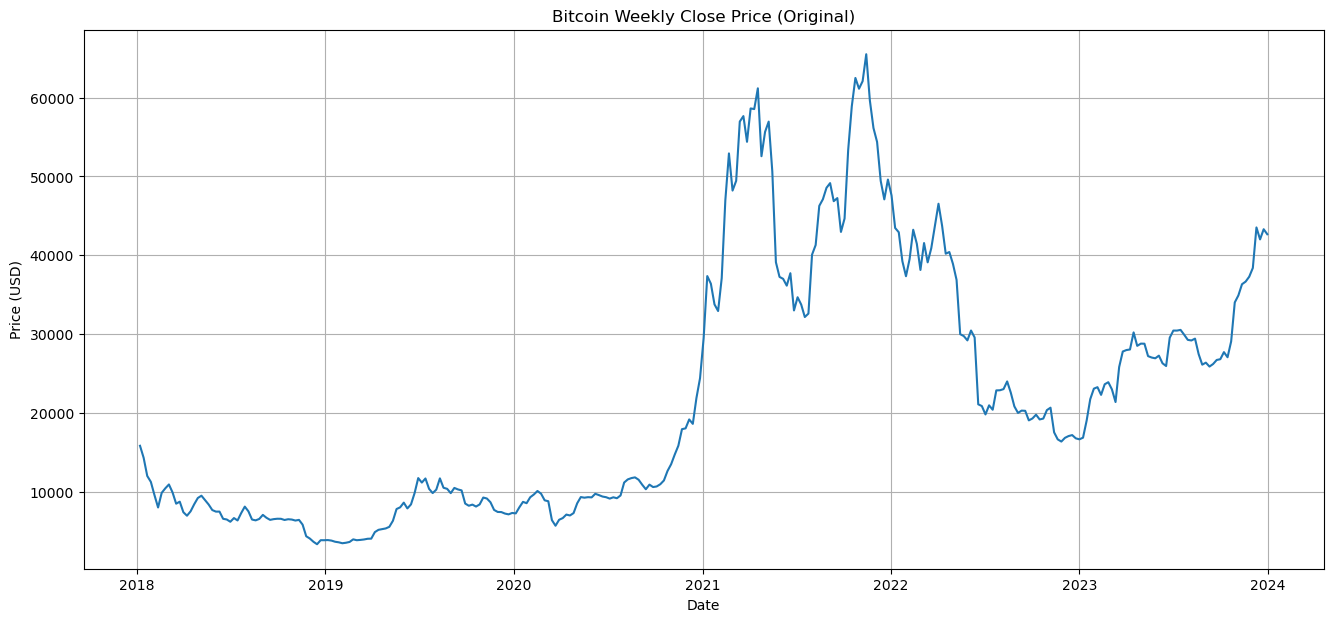

In [3]:
# --- 3. Exploratory Data Analysis (EDA) ---
print("\n--- 3. Exploratory Data Analysis (EDA) ---")
plt.figure(figsize=(16, 7))
plt.plot(data_to_model)
plt.title('Bitcoin Weekly Close Price (Original)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

# Observe: Clear upward/downward trends, high volatility, increasing variance over time.
print("variance :",data_to_model['BTC-USD'].var())


--- 4. Data Transformation (Log & Differencing) ---


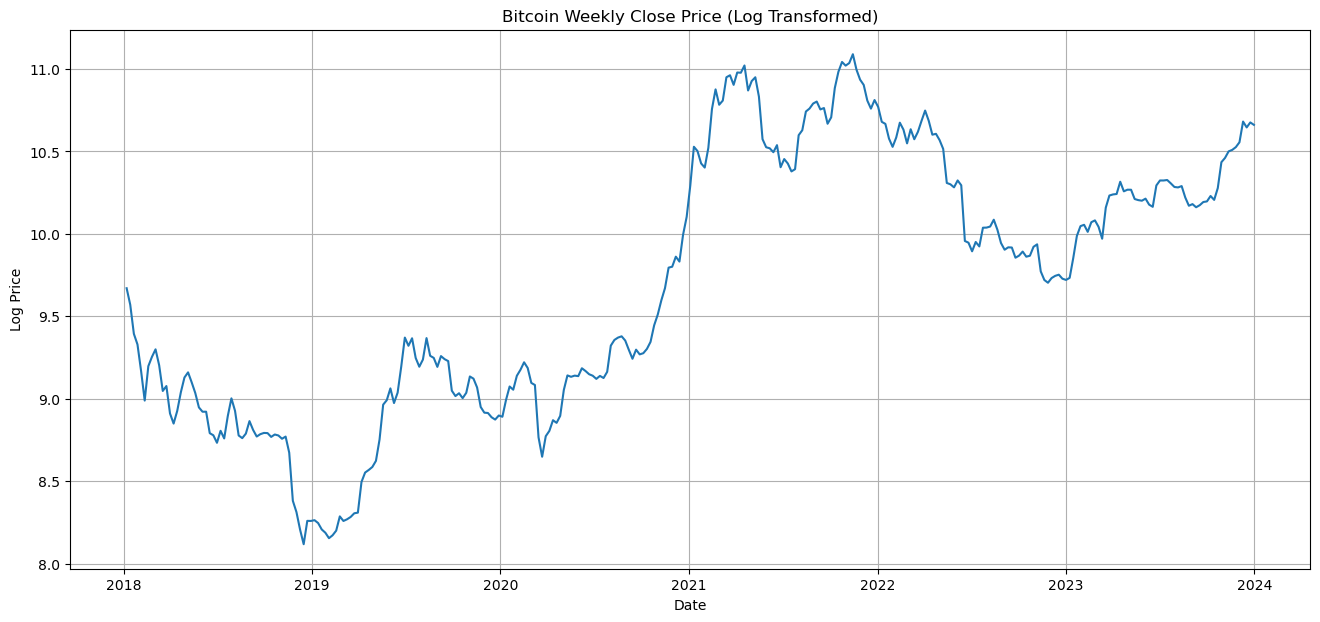

In [4]:
# --- 4. Data Transformation (Log & Differencing) ---
print("\n--- 4. Data Transformation (Log & Differencing) ---")

# 4.1 Log Transformation for Variance Stabilization (Homoscedasticity)
# Bitcoin price often exhibits increasing variance with increasing price. Log transformation helps.
log_data = np.log(data_to_model)

plt.figure(figsize=(16, 7))
plt.plot(log_data)
plt.title('Bitcoin Weekly Close Price (Log Transformed)')
plt.xlabel('Date')
plt.ylabel('Log Price')
plt.grid(True)
plt.show()
# Observe: Variance looks more stable now.
print("Variance : ",log_data['BTC-USD'].var())

In [20]:
# 4.2 Differencing for Mean Stationarity
# Helper function for ADF test
def adf_test_results(series, name='Series'):
    # Dropping NaNs for ADF test in case of differencing
    series_clean = series.dropna()
    if len(series_clean) < 10: # ADF test needs sufficient observations
        print(f"  {name}: Not enough data for ADF test after dropping NaNs. Length: {len(series_clean)}")
        return
    result = adfuller(series_clean)
    print(f'\n--- Augmented Dickey-Fuller Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f"Conclusion: Reject H0. {name} is likely stationary.")
    else:
        print(f"Conclusion: Do not reject H0. {name} is likely non-stationary.")

# Test stationarity of log-transformed data
adf_test_results(log_data, 'Log Transformed Data')



--- Augmented Dickey-Fuller Test for Log Transformed Data ---
ADF Statistic: -0.9086
p-value: 0.7851
Critical Values:
  1%: -3.4516
  5%: -2.8709
  10%: -2.5717
Conclusion: Do not reject H0. Log Transformed Data is likely non-stationary.


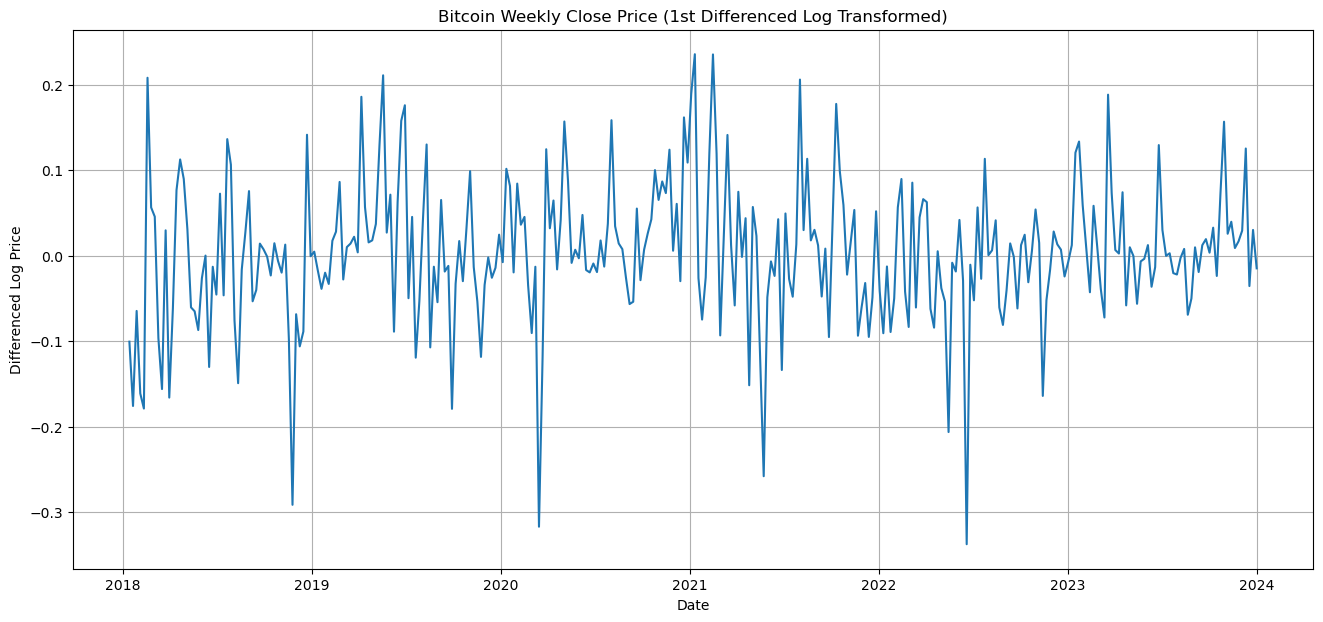


--- Augmented Dickey-Fuller Test for 1st Differenced Log Transformed Data ---
ADF Statistic: -13.4099
p-value: 0.0000
Critical Values:
  1%: -3.4516
  5%: -2.8709
  10%: -2.5717
Conclusion: Reject H0. 1st Differenced Log Transformed Data is likely stationary.


In [21]:
# First-order non-seasonal differencing
diff1_log_data = log_data.diff(1).dropna()
plt.figure(figsize=(16, 7))
plt.plot(diff1_log_data)
plt.title('Bitcoin Weekly Close Price (1st Differenced Log Transformed)')
plt.xlabel('Date')
plt.ylabel('Differenced Log Price')
plt.grid(True)
plt.show()

adf_test_results(diff1_log_data, '1st Differenced Log Transformed Data')
# For Bitcoin, d=1 is usually sufficient for non-seasonal trend removal.

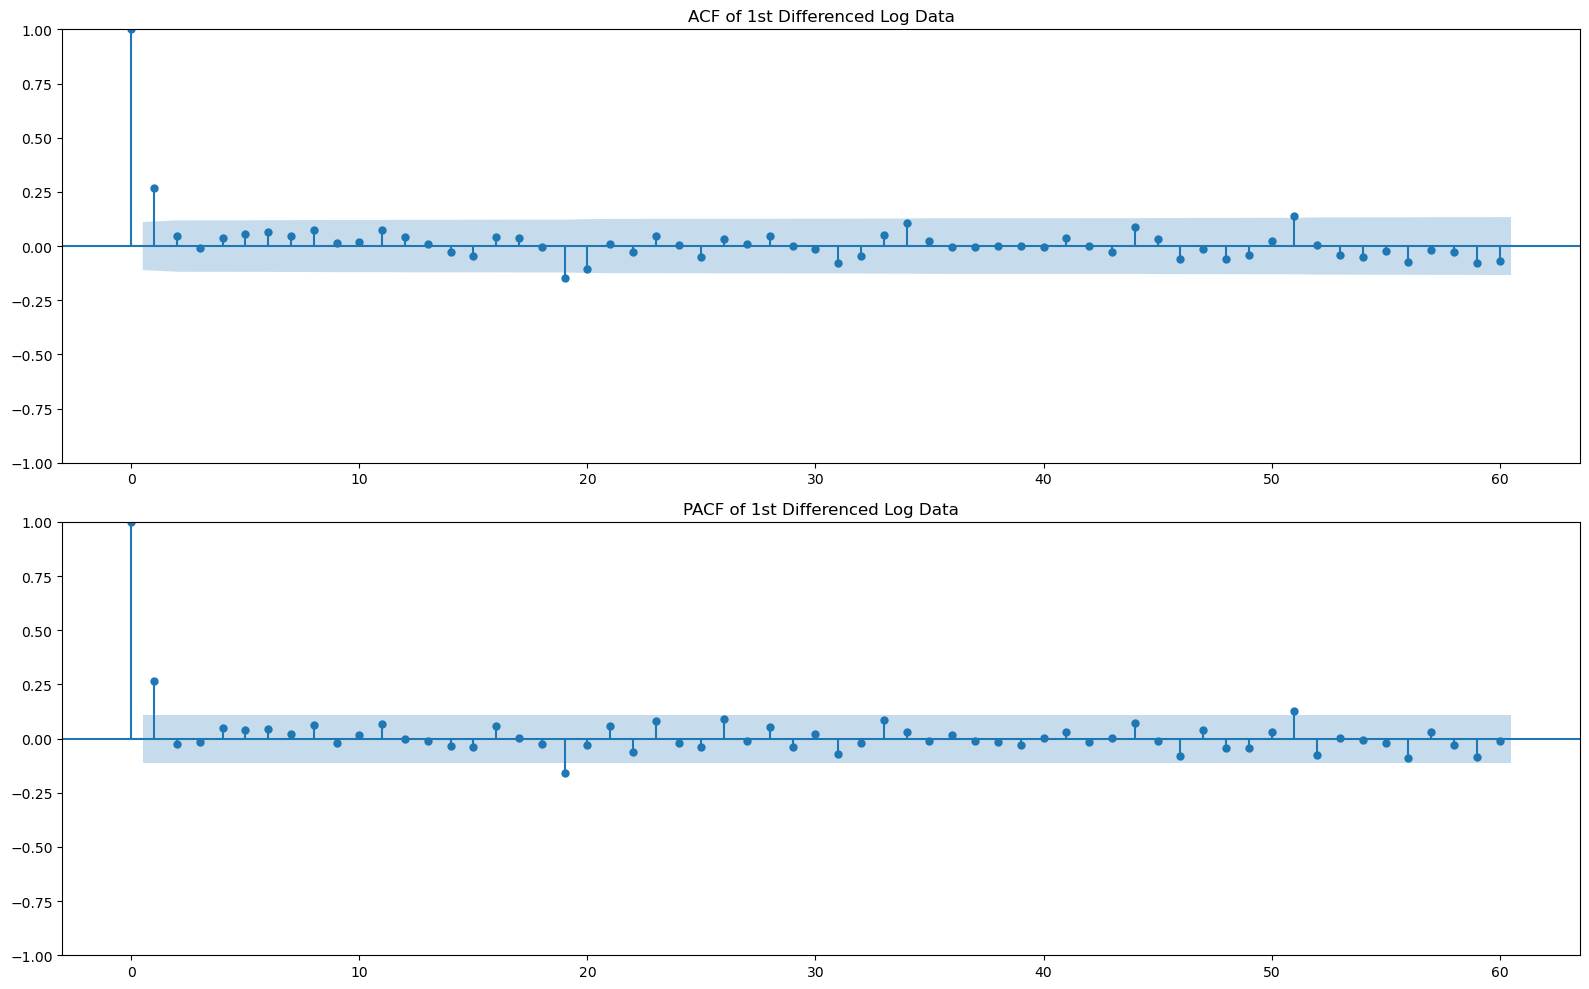

In [23]:
# Check for seasonality visually using ACF/PACF of differenced data
# Weekly data, so seasonal period 's' would be 52 for yearly cycle.
# However, financial data like Bitcoin often doesn't have strong typical seasonality.
# Let's inspect for hints of weekly or monthly patterns (e.g., 4 for monthly on weekly data)
# Plot ACF/PACF of 1st differenced log data for ARIMA order identification (p,q)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(diff1_log_data, ax=axes[0], lags=60, title='ACF of 1st Differenced Log Data')
plot_pacf(diff1_log_data, ax=axes[1], lags=60, title='PACF of 1st Differenced Log Data')
plt.tight_layout()
plt.show()
# We might see a few significant lags, but no strong regular spikes like typical seasonality (e.g., every 52 lags).



--- 5. Decomposition (STL) ---
STL Decomposition done on Log Transformed Data.


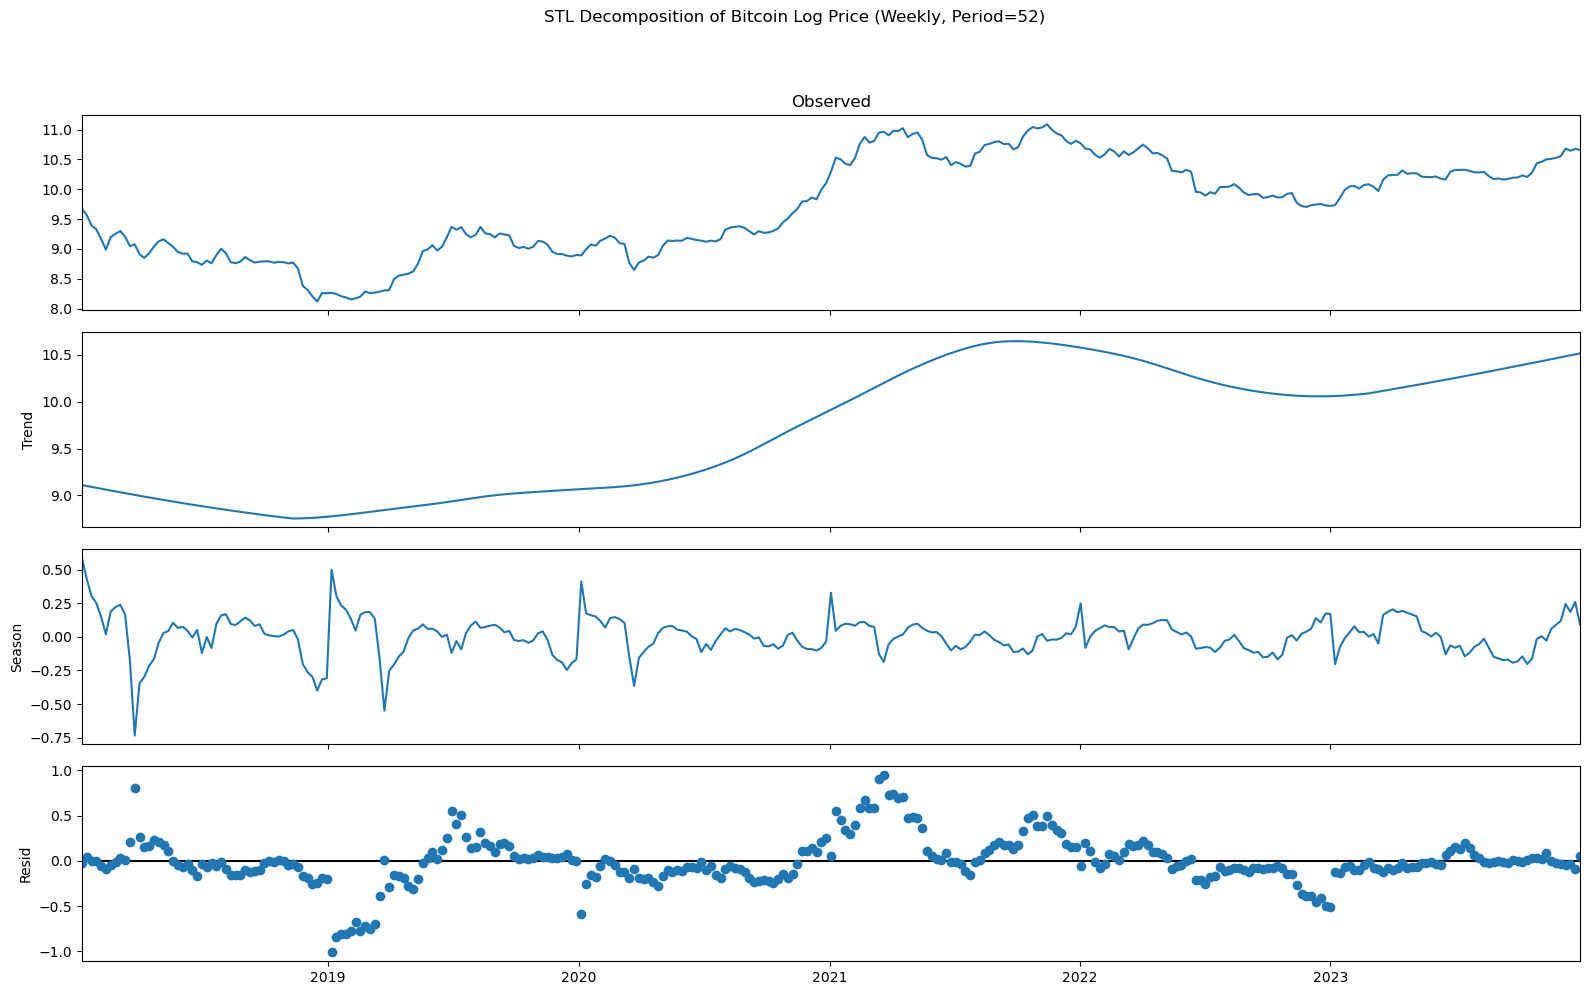

Trend Component Head:
Date
2018-01-07    9.109600
2018-01-14    9.099834
2018-01-21    9.090108
2018-01-28    9.080425
2018-02-04    9.070787
Freq: W-SUN, Name: trend, dtype: float64
Seasonal Component Head:
Date
2018-01-07    0.585234
2018-01-14    0.430433
2018-01-21    0.302853
2018-01-28    0.250964
2018-02-04    0.148170
Freq: W-SUN, Name: season, dtype: float64
Residual Component Head:
Date
2018-01-07   -0.024598
2018-01-14    0.039319
2018-01-21    0.000659
2018-01-28   -0.002415
2018-02-04   -0.051271
Freq: W-SUN, Name: resid, dtype: float64


In [24]:
# --- 5. Decomposition (STL) ---
print("\n--- 5. Decomposition (STL) ---")
# Apply STL to the original data (or log-transformed if you want to see components on that scale)
# Using log_data for decomposition as its variance is more stable
# Period for weekly data: 52 for yearly seasonality, 4 for monthly seasonality (if any)
# Bitcoin might not have strong explicit seasonality, but STL can still help separate a smoother trend.
# Let's use a conservative period (e.g., 4 for monthly on weekly data, or 52 for yearly)
# Given the volatility, a smaller `seasonal` and `trend` window for `STL` can be useful initially.
# If no clear seasonality, `period=1` or skipping `seasonal` parameter effectively runs `LOESS` for trend.

try:
    # Ensure log_data has enough points for the chosen period
    if len(log_data) > 52 * 2: # At least two full periods for robust STL
        stl = STL(log_data, period=52, robust=True, seasonal=13, trend=None) # trend=None lets STL choose based on period/seasonal
        res = stl.fit()
        print("STL Decomposition done on Log Transformed Data.")
        fig_stl = res.plot()
        fig_stl.set_size_inches(16, 10)
        fig_stl.suptitle('STL Decomposition of Bitcoin Log Price (Weekly, Period=52)', y=1.02)
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()

        # You can now analyze trend_component, seasonal_component, residual_component
        # For Bitcoin, seasonal component often looks like noise unless very strong, short cycles.
        print(f"Trend Component Head:\n{res.trend.head()}")
        print(f"Seasonal Component Head:\n{res.seasonal.head()}")
        print(f"Residual Component Head:\n{res.resid.head()}")

    else:
        print("Not enough data points for robust STL decomposition with period=52. Skipping STL plot.")
        res = None

except Exception as e:
    print(f"STL Decomposition failed (often due to too short series or period mismatch): {e}")
    print("Skipping STL decomposition for now due to error.")
    res = None



--- 6. Smoothing (Explicit Example) ---


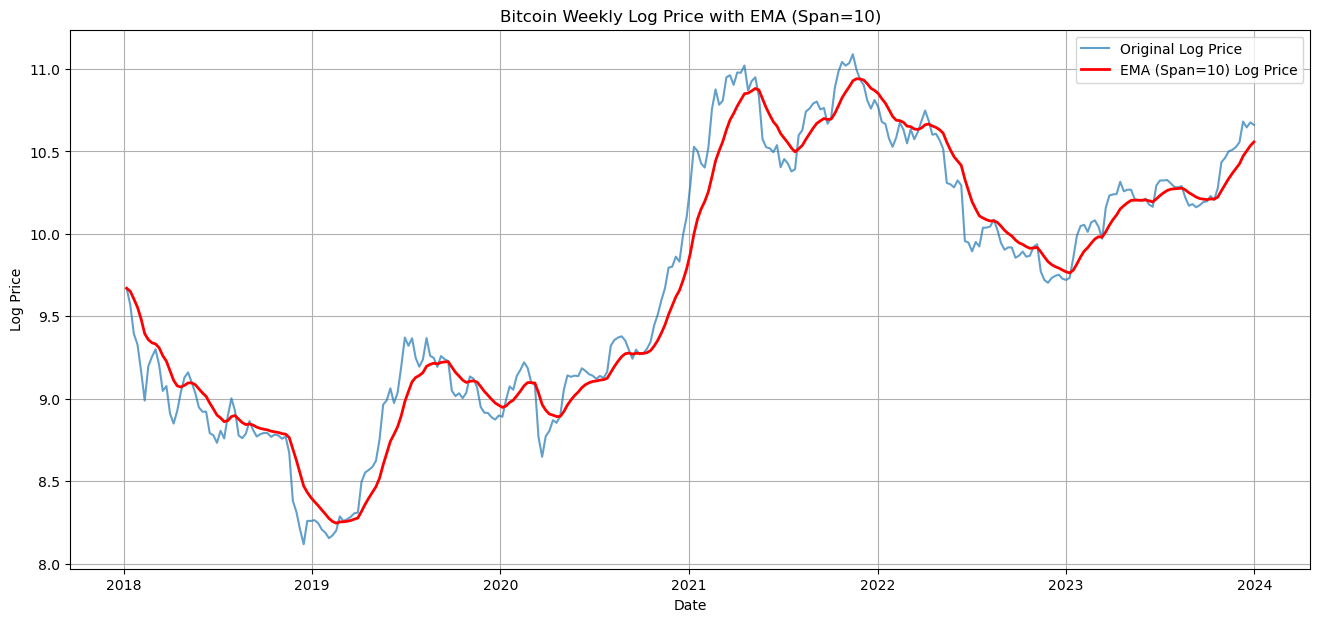

In [25]:
# --- 6. Smoothing (Explicit Example) ---
print("\n--- 6. Smoothing (Explicit Example) ---")
# Exponential Moving Average (EMA) is common for financial data
# Span/Window determines smoothness
ema_span = 10 # 10-week EMA on log data
smoothed_log_data = log_data.ewm(span=ema_span, adjust=False).mean()

plt.figure(figsize=(16, 7))
plt.plot(log_data, label='Original Log Price', alpha=0.7)
plt.plot(smoothed_log_data, label=f'EMA (Span={ema_span}) Log Price', color='red', linewidth=2)
plt.title(f'Bitcoin Weekly Log Price with EMA (Span={ema_span})')
plt.xlabel('Date')
plt.ylabel('Log Price')
plt.grid(True)
plt.legend()
plt.show()
# This smoothing is more for visualization or to provide input to a simpler forecasting model,
# not typically a direct step before ARIMA/SARIMA which handle smoothing internally via AR/MA components.




--- 7. Stationarity Testing (Re-confirm) ---

--- Augmented Dickey-Fuller Test for 1st Differenced Log Transformed Data (for ARIMA) ---
ADF Statistic: -13.4099
p-value: 0.0000
Critical Values:
  1%: -3.4516
  5%: -2.8709
  10%: -2.5717
Conclusion: Reject H0. 1st Differenced Log Transformed Data (for ARIMA) is likely stationary.


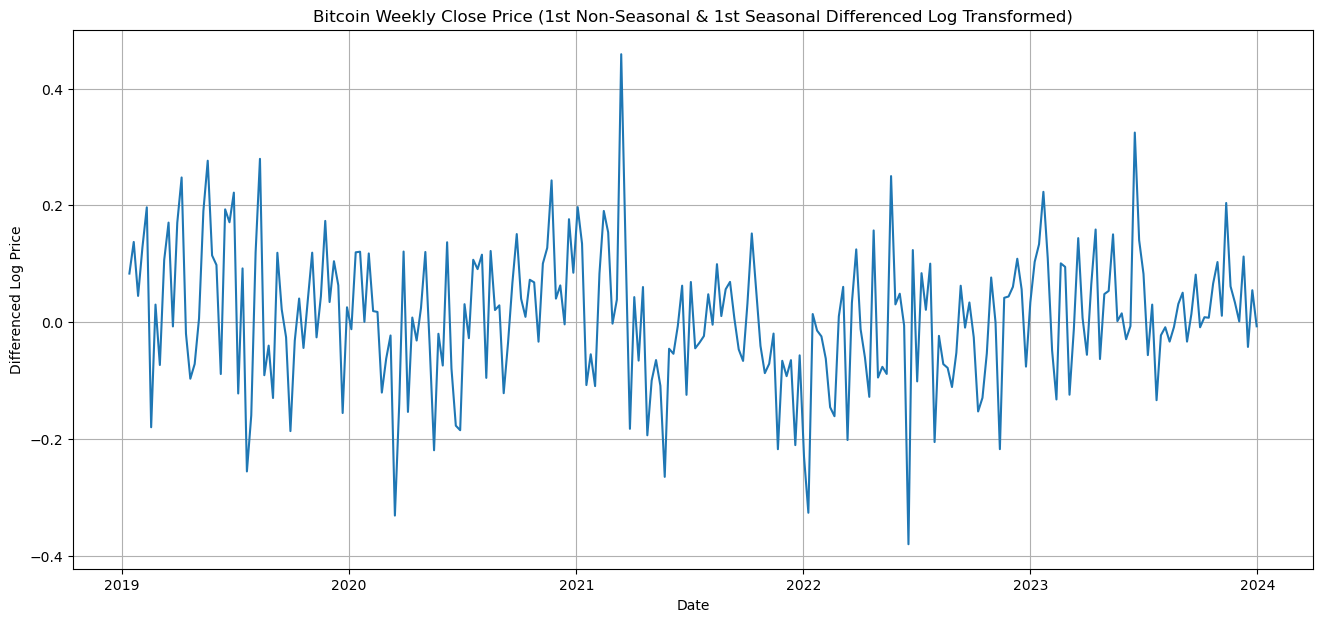


--- Augmented Dickey-Fuller Test for 1st Non-Seasonal & 1st Seasonal Differenced Log Transformed Data (for SARIMA) ---
ADF Statistic: -4.7089
p-value: 0.0001
Critical Values:
  1%: -3.4564
  5%: -2.8730
  10%: -2.5729
Conclusion: Reject H0. 1st Non-Seasonal & 1st Seasonal Differenced Log Transformed Data (for SARIMA) is likely stationary.


In [26]:
# --- 7. Stationarity Testing (Re-confirm for modeling) ---
# We already did this in step 4, but it's good to re-emphasize the importance
# The goal is for the series to be stationary *before* fitting simple ARMA or to determine d,D for ARIMA/SARIMA.
print("\n--- 7. Stationarity Testing (Re-confirm) ---")
adf_test_results(diff1_log_data, '1st Differenced Log Transformed Data (for ARIMA)')
# If p-value > 0.05 here, you might need more differencing (d=2) or look at seasonal differencing.

# For SARIMA, we also consider seasonal differencing D.
# If we suspect weekly seasonality on weekly data (unlikely for price but for demo), D=1, s=52
# Let's try seasonal differencing (D=1, s=52) after non-seasonal differencing (d=1) for completeness
diff_seasonal_log_data = log_data.diff(1).diff(52).dropna()
if len(diff_seasonal_log_data) > 10:
    plt.figure(figsize=(16, 7))
    plt.plot(diff_seasonal_log_data)
    plt.title('Bitcoin Weekly Close Price (1st Non-Seasonal & 1st Seasonal Differenced Log Transformed)')
    plt.xlabel('Date')
    plt.ylabel('Differenced Log Price')
    plt.grid(True)
    plt.show()
    adf_test_results(diff_seasonal_log_data, '1st Non-Seasonal & 1st Seasonal Differenced Log Transformed Data (for SARIMA)')
else:
    print("Not enough data points for 1st Non-Seasonal & 1st Seasonal Differencing.")


In [27]:
# --- 8. Model Identification (ARIMA/SARIMA Order Selection) ---
print("\n--- 8. Model Identification (ARIMA/SARIMA Order Selection) ---")
# Split data into training and testing
train_size = int(len(log_data) * 0.8)
train_data = log_data[:train_size]
test_data = log_data[train_size:]

print(f"Training data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")
forecast_horizon = len(test_data)




--- 8. Model Identification (ARIMA/SARIMA Order Selection) ---
Training data length: 250
Test data length: 63



--- Auto-ARIMA for Non-Seasonal ARIMA (p,1,q) ---
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-499.337, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-516.687, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-515.640, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-501.318, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-514.751, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-514.740, Time=0.33 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-512.723, Time=0.26 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-518.681, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-516.744, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-516.734, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-517.630, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-514.716, Time=0.20 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 1.838 seconds
                               SARIMA

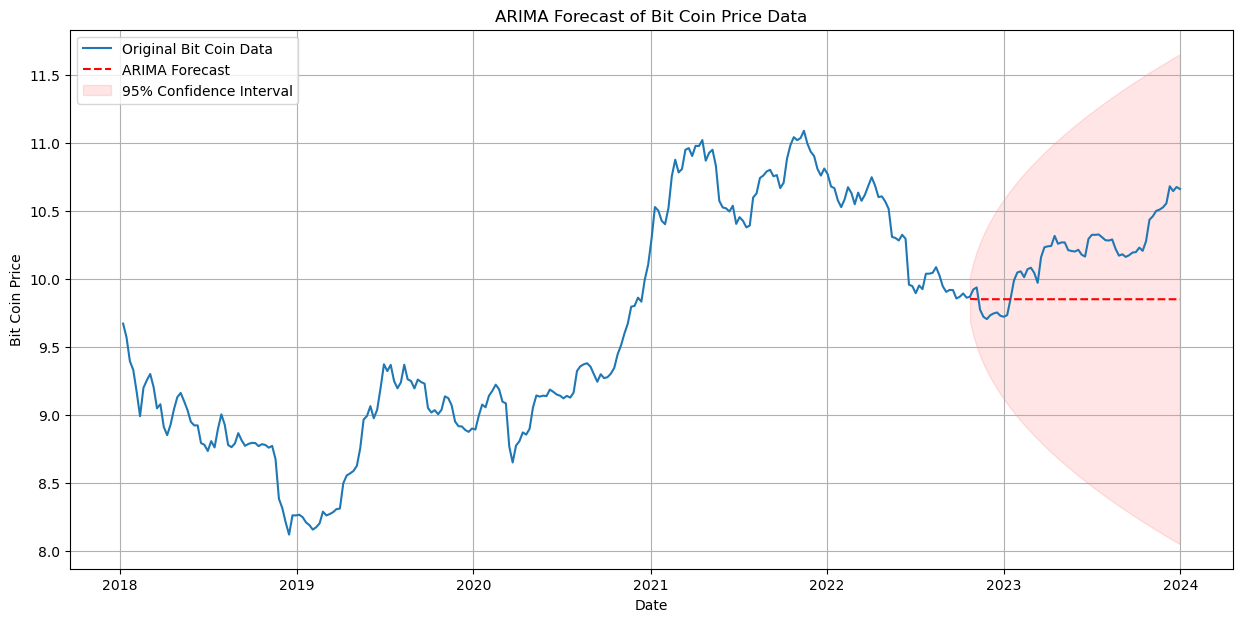

In [37]:
# 8.1 ARIMA Model Selection (Non-Seasonal)
# We assume d=1 from previous ADF test. Let auto_arima find p and q.
print("\n--- Auto-ARIMA for Non-Seasonal ARIMA (p,1,q) ---")
# We set seasonal=False for ARIMA
arima_model_fit = pm.auto_arima(train_data,
                                 start_p=0, start_q=0,
                                 max_p=5, max_q=5,
                                 d=1,                # Fixed non-seasonal differencing
                                 seasonal=False,     # No seasonality
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True,
                                 n_jobs=-1,
                                 information_criterion='aic')
print(arima_model_fit.summary())

print("\n--- Non-Seasonal ARIMA Model Training & Forecasting ---")
# Forecast with chosen ARIMA model
arima_forecast_log = arima_model_fit.predict(n_periods=forecast_horizon)
arima_conf_int_log = arima_model_fit.predict(n_periods=forecast_horizon, return_conf_int=True)[1]
arima_forecast_series_log = pd.Series(arima_forecast_log, index=test_data.index)
arima_conf_int_df_log = pd.DataFrame(arima_conf_int_log, index=test_data.index, columns=['lower', 'upper'])

# -------------------------------
plt.figure(figsize=(15, 7))
plt.plot(log_data, label='Original Bit Coin Data')
plt.plot(arima_forecast_series_log, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(arima_conf_int_df_log.index, arima_conf_int_df_log.iloc[:, 0], arima_conf_int_df_log.iloc[:, 1], color='red', alpha=0.1, label='95% Confidence Interval')
plt.title('ARIMA Forecast of Bit Coin Price Data')
plt.xlabel('Date')
plt.ylabel('Bit Coin Price')
plt.grid(True)
plt.legend()
plt.show()


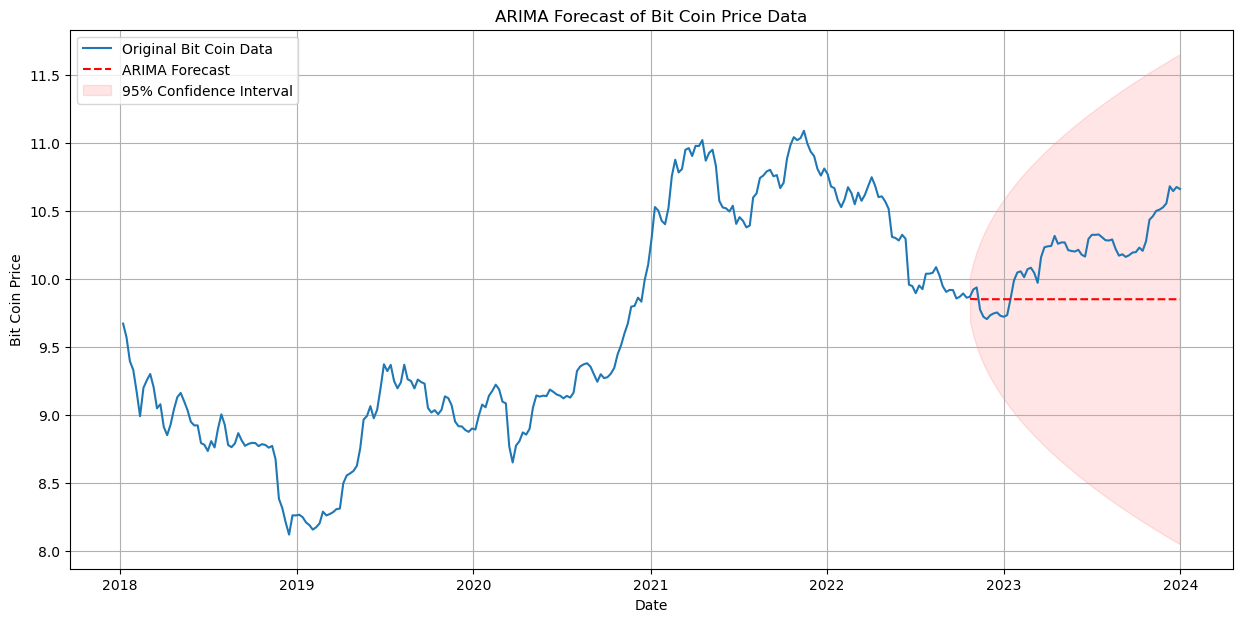

In [ ]:
# Forecast with chosen ARIMA model
arima_forecast_log = arima_model_fit.predict(n_periods=forecast_horizon)
arima_conf_int_log = arima_model_fit.predict(n_periods=forecast_horizon, return_conf_int=True)[1]
arima_forecast_series_log = pd.Series(arima_forecast_log, index=test_data.index)
arima_conf_int_df_log = pd.DataFrame(arima_conf_int_log, index=test_data.index, columns=['lower', 'upper'])


# Forecast using the best SARIMA model found by auto_arima
sarima_forecast_results = sarima_auto_model.predict(n_periods=forecast_horizon_sarima, return_conf_int=True)
sarima_mean_forecast = pd.Series(sarima_forecast_results[0], index=pd.date_range(start=airline_series.index[-1] + pd.DateOffset(months=1), periods=forecast_horizon_sarima, freq='MS'))
sarima_conf_int = pd.DataFrame(sarima_forecast_results[1], index=sarima_mean_forecast.index, columns=['lower', 'upper'])

# Plotting SARIMA forecast
plt.figure(figsize=(15, 7))
plt.plot(airline_series, label='Original Airline Passengers Data')
plt.plot(sarima_mean_forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='red', alpha=0.1, label='95% Confidence Interval')
plt.title('SARIMA Forecast of Airline Passengers Data')
plt.xlabel('Date')
plt.ylabel('Passengers (x1000)')
plt.grid(True)
plt.legend()
plt.show()


--- Auto-ARIMA for SARIMA (p,d,q)(P,D,Q,s) ---
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=-261.793, Time=1.78 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=-314.448, Time=31.17 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=inf, Time=65.05 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=-268.235, Time=1.20 sec
 ARIMA(1,1,0)(2,1,0)[52]             : AIC=-320.998, Time=56.71 sec
 ARIMA(1,1,0)(2,1,1)[52]             : AIC=inf, Time=204.92 sec
 ARIMA(1,1,0)(1,1,1)[52]             : AIC=inf, Time=102.75 sec
 ARIMA(0,1,0)(2,1,0)[52]             : AIC=-306.271, Time=46.85 sec
 ARIMA(2,1,0)(2,1,0)[52]             : AIC=-319.060, Time=158.08 sec
 ARIMA(1,1,1)(2,1,0)[52]             : AIC=-319.082, Time=148.09 sec
 ARIMA(0,1,1)(2,1,0)[52]             : AIC=-319.235, Time=78.46 sec
 ARIMA(2,1,1)(2,1,0)[52]             : AIC=-317.062, Time=109.61 sec
 ARIMA(1,1,0)(2,1,0)[52] intercept   : AIC=-319.232, Time=76.18 sec

Best model:  ARIMA(1,1,0)(2,1,0)[52]

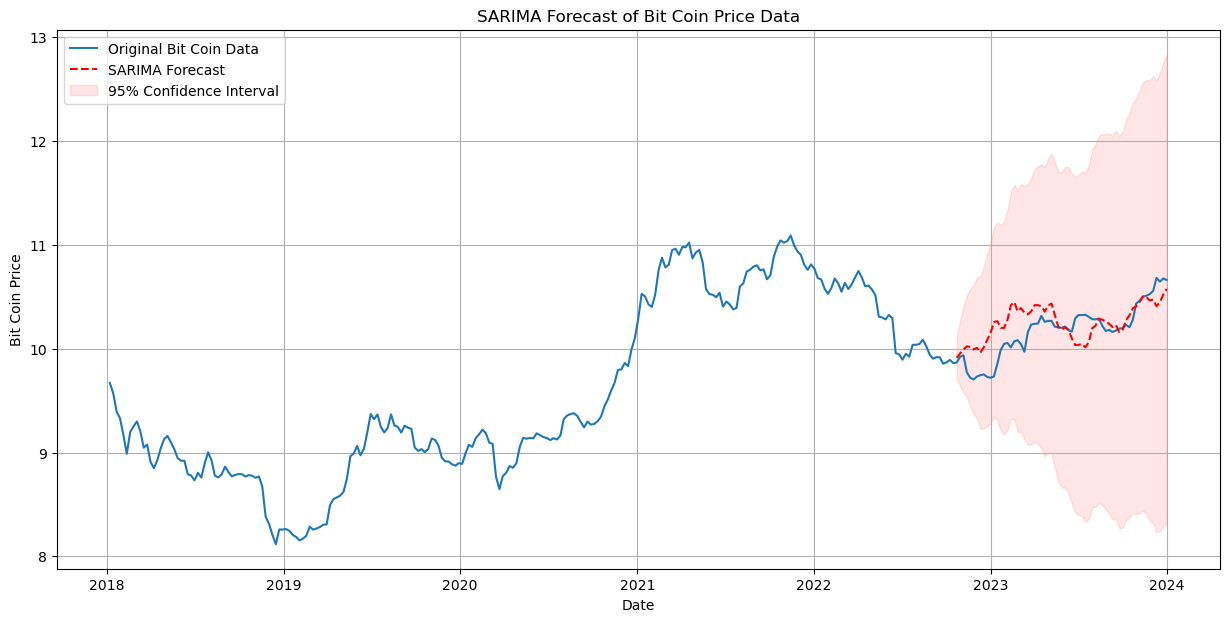

In [38]:
# 8.2 SARIMA Model Selection (Seasonal, if applicable)
# For weekly Bitcoin, a strong s=52 is unlikely. We might consider s=4 (monthly on weekly data) if we suspect some short cycles.
# Let's run with s=52 to show the capability, but auto_arima might select P=0, Q=0 if no strong seasonality.
print("\n--- Auto-ARIMA for SARIMA (p,d,q)(P,D,Q,s) ---")
# We assume d=1 (for trend). Let auto_arima decide if seasonal differencing D is needed and seasonal AR/MA orders.
# Max D=1 for seasonal differencing, max P/Q for seasonal AR/MA.
sarima_model_fit = pm.auto_arima(train_data,
                                  start_p=0, start_q=0,
                                  max_p=5, max_q=5,
                                  m=52,                # Seasonal period (52 weeks for yearly)
                                  d=1,                 # Non-seasonal differencing
                                  start_P=0, start_Q=0,
                                  max_P=2, max_Q=2,
                                  D=1,                 # Allow seasonal differencing
                                  seasonal=True,       # Enable seasonality
                                  trace=True,
                                  error_action='ignore',
                                  suppress_warnings=True,
                                  stepwise=True,
                                  n_jobs=-1,
                                  information_criterion='aic')
print(sarima_model_fit.summary())

print("\n--- Non-Seasonal SARIMA Model Training & Forecasting ---")
# Forecast with chosen SARIMA model
sarima_forecast_log = sarima_model_fit.predict(n_periods=forecast_horizon)
sarima_conf_int_log = sarima_model_fit.predict(n_periods=forecast_horizon, return_conf_int=True)[1]
sarima_forecast_series_log = pd.Series(sarima_forecast_log, index=test_data.index)
sarima_conf_int_df_log = pd.DataFrame(sarima_conf_int_log, index=test_data.index, columns=['lower', 'upper'])

# -------------------------------
plt.figure(figsize=(15, 7))
plt.plot(log_data, label='Original Bit Coin Data')
plt.plot(sarima_forecast_series_log, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(sarima_conf_int_df_log.index, sarima_conf_int_df_log.iloc[:, 0], sarima_conf_int_df_log.iloc[:, 1], color='red', alpha=0.1, label='95% Confidence Interval')
plt.title('SARIMA Forecast of Bit Coin Price Data')
plt.xlabel('Date')
plt.ylabel('Bit Coin Price')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# --- 9. Model Training & Forecasting ---


# --- 10. Inverse Transformation ---
print("\n--- 10. Inverse Transformation ---")
# Convert forecasts back to original scale (USD)
arima_forecast_usd = np.exp(arima_forecast_series_log)
arima_lower_usd = np.exp(arima_conf_int_df_log['lower'])
arima_upper_usd = np.exp(arima_conf_int_df_log['upper'])

In [ ]:
Explanation of the "Tough" Example Workflow:

    Data Acquisition (yfinance): We fetch BTC-USD daily data. This data is inherently challenging due to its high volatility and non-linear trends.

    Data Preprocessing:

        Missing Values: Financial data can have gaps (e.g., weekends, holidays if not traded 24/7). ffill().bfill() ensures no NaNs, which would break the models.

        Resampling (.resample('W').mean()): Daily cryptocurrency data is often too noisy for classical ARIMA/SARIMA models. Resampling to weekly averages significantly reduces noise and computational load, making the underlying patterns (trends, weaker seasonality) more discernible. This is a crucial data treatment for high-frequency noisy data.

    Exploratory Data Analysis (EDA):

        The initial plot of Bitcoin price clearly shows its highly non-stationary nature (strong trends, not mean-reverting) and heteroscedasticity (variance appears to increase with price level).

    Data Transformation:

        Log Transformation (np.log()): This is a critical step for financial time series like prices. It helps to:

            Stabilize Variance (Homoscedasticity): If the amplitude of fluctuations increases with the mean, a log transformation often makes the variance more constant, which is an assumption of ARIMA models.

            Linearize Exponential Trends: If the growth is exponential, log transformation can turn it into a linear trend, which is easier for ARIMA's differencing to handle.

        Differencing (.diff(1)):

            The log-transformed data still has a strong trend. First-order non-seasonal differencing (d=1) removes this trend, making the series mean-stationary.

            The ADF test confirms non-stationarity of the original/log series and then stationarity of the differenced series.

    Decomposition (STL):

        We apply STL to the log-transformed data. While Bitcoin's seasonality isn't calendar-driven like sales data, we still use period=52 (for weekly data) to attempt to extract any subtle yearly patterns or just to get a smoother trend and a more isolated residual.

        robust=True makes STL less sensitive to extreme outliers, common in financial data.

        The resulting plots show the smoothed trend, any seasonal component identified, and the residual (noise) after removing trend and seasonality. For Bitcoin, the "seasonal" component might often look like noise, emphasizing that strong calendar seasonality isn't a primary driver.

    Smoothing (Explicit Example - EMA):

        We demonstrate applying an Exponential Moving Average (EMA) directly to the log-transformed data. This is primarily for visualization or for use with simpler forecasting models. ARIMA/SARIMA models implicitly handle smoothing through their AR and MA components, so this isn't a required step before fitting them, but it helps understand how explicit smoothing works.

    Stationarity Testing (Re-confirmation):

        This section re-emphasizes the role of ADF tests and ACF/PACF plots after transformations.

        The ACF/PACF plots of the differenced log data are crucial for visually identifying the p and q orders for the ARIMA model. For SARIMA, you'd also look for spikes at seasonal lags to identify P and Q (and whether D is needed).

        For Bitcoin, the ACF/PACF of differenced data will likely show quick decay, suggesting low p and q orders, and potentially no significant seasonal spikes at s=52 (meaning P=0, Q=0 for SARIMA on yearly weekly cycles).

    Model Identification (Auto-ARIMA):

        We split the data into training (80%) and testing (20%).

        pmdarima.auto_arima is paramount here for SARIMA:

            d=1: We confidently set non-seasonal differencing to 1 because the initial ADF test on log data likely indicates this.

            m=52: We specify the seasonal period for weekly data (52 weeks in a year). auto_arima will then test if D=1 (seasonal differencing) and P, Q (seasonal AR/MA) are needed.

            seasonal=True: Tells auto_arima to consider seasonal components.

            trace=True, stepwise=True, n_jobs=-1: For efficient and informative model selection.

            error_action='ignore', suppress_warnings=True: Good for automated large-scale use, but temporarily set to False / 'warn' if you encounter NaN issues to debug.

        auto_arima will output the best ARIMA and SARIMA orders based on AIC. For Bitcoin, it often finds low p,q and might even set P,Q to zero for weekly seasonality unless a very long history is used to detect subtle patterns.

    Model Training & Forecasting:

        The auto_arima object is already fitted. We use its predict() method to generate forecasts (and confidence intervals) on the log scale.

    Inverse Transformation:

        This is a critical step: np.exp() is used to convert the log-transformed forecasts and confidence intervals back to the original USD price scale. This gives you directly interpretable price predictions.

    Model Evaluation:

        Metrics (MAE, RMSE, MAPE): These quantitative metrics help compare the performance of ARIMA vs. SARIMA on the test set, measured in original USD. RMSE is sensitive to large errors, MAE is less so, and MAPE gives a percentage error.

        Visual Plot: The plot of original data, training data, actual test data, and forecasts (with confidence intervals) is the most intuitive way to assess forecast quality. For Bitcoin, forecasts might struggle with sudden extreme price movements, and confidence intervals will widen significantly into the future, reflecting high uncertainty.

        Residual Analysis: Plotting ACF/PACF of the residuals (on the log-transformed scale) is crucial. Ideally, residuals should resemble white noise (no significant spikes after lag 0). If there are significant spikes, it means the model hasn't captured all the information in the series, and a different model or more fine-tuning of orders might be needed. For Bitcoin, some residual autocorrelation is common due to its complex nature, but the goal is to minimize it.

This comprehensive example tackles the complexities of financial time series with ARIMA/SARIMA, emphasizing crucial preprocessing and diagnostic steps. Remember that for extremely volatile and non-linear data like Bitcoin, more advanced models (e.g., GARCH for volatility, Prophet for non-linear trends, or deep learning models) might offer further improvements, but ARIMA/SARIMA remains a powerful baseline.